In [ ]:
from ipow.generators import (
    HMACDRBG,
    LCGGenerator,
    LogisticMapGenerator,
    MT19937Generator,
    MockTRNG,
    PCG64Generator,
    SystemCSPRNG,
)
from ipow.tests import ValidationConfig, validate_generator, run_visual_tests

In [8]:
import json

cfg = ValidationConfig(n_numbers=5000, n_bits=10000)

## Linear Congruential Generator (LCG)

Model matematyczny:
            
$$X_{n+1} = (aX_n + c) \mod m $$

gdzie:
- `X_n` oznacza aktualny stan generatora,
- `a` jest mnożnikiem,
- `c` jest przyrostem,
- `m` jest modułem.
          
Parametry (Knuth's MMIX parameters):

- a=6364136223846793005
- c=1442695040888963407
- m=2^64

Charakterystyka: Reprezentant klasycznych generatorów PRNG. Jest to implementacja "surowa" – bez dodatkowych permutacji wyjścia, co pozwala na analizę typowych wad LCG (np. korelacje w niższych bitach).

{
  "generator": "LCG",
  "summary_numbers": {
    "count": 5000.0,
    "mean": 9.278974880883964e+18,
    "variance": 2.851268695335549e+37,
    "std": 5.33972723585723e+18,
    "min": 1.2552162437186158e+16,
    "max": 1.8446325592286941e+19
  },
  "summary_floats": {
    "count": 5000.0,
    "mean": 0.5028495600924291,
    "variance": 0.08236152419013328,
    "std": 0.28698697564546943,
    "min": 4.124130827906766e-06,
    "max": 0.9996267390337736
  },
  "bit_balance": {
    "count": 10000,
    "zeros": 5083,
    "ones": 4917,
    "p_zero": 0.5083,
    "p_one": 0.4917
  },
  "serial_pairs": {
    "00": 2549,
    "01": 2534,
    "10": 2533,
    "11": 2383
  },
  "tests": {
    "monobit": {
      "statistic": 1.66,
      "p_value": 0.09691445253344563,
      "pass": true
    },
    "runs": {
      "statistic": 5068.0,
      "p_value": 0.16515578513615975,
      "pass": true
    },
    "chi_square_uint64_mod_256": {
      "statistic": 3.2640000000000002,
      "p_value": 1.0,
      "

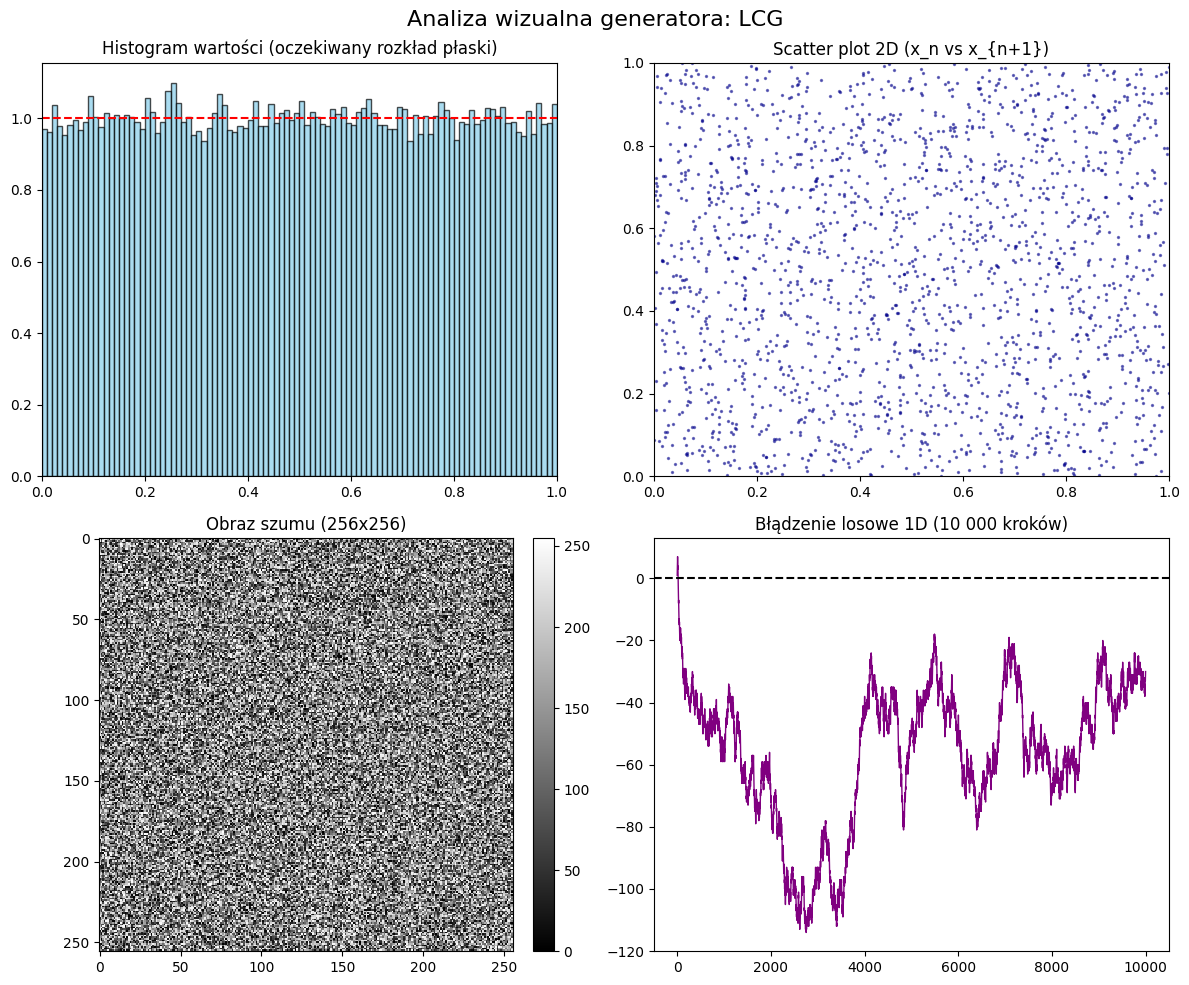

In [ ]:
generator = LCGGenerator(seed=12345)
results = validate_generator(generator, cfg)
print(json.dumps(results, indent=2))
run_visual_tests(generator)

## Mersenne Twister (MT19937)

Implementacja: Wykorzystano bibliotekę `numpy.random.MT19937`.

Charakterystyka: Najpopularniejszy generator ogólnego przeznaczenia (używany m.in. w Pythonie i Excelu). Posiada bardzo duży okres (2^19937−1) i zapewnia równomierność rozkładu aż do 623 wymiarów. Nie jest jednak bezpieczny kryptograficznie.

{
  "generator": "MT19937",
  "summary_numbers": {
    "count": 5000.0,
    "mean": 9.211648694440866e+18,
    "variance": 2.7785698402487802e+37,
    "std": 5.271214129826998e+18,
    "min": 6569719550886596.0,
    "max": 1.8445228747456528e+19
  },
  "summary_floats": {
    "count": 5000.0,
    "mean": 0.5068209697862948,
    "variance": 0.08109789993191409,
    "std": 0.284776930125869,
    "min": 0.00013966917374119703,
    "max": 0.9996568531282698
  },
  "bit_balance": {
    "count": 10000,
    "zeros": 5016,
    "ones": 4984,
    "p_zero": 0.5016,
    "p_one": 0.4984
  },
  "serial_pairs": {
    "00": 2500,
    "01": 2515,
    "10": 2515,
    "11": 2469
  },
  "tests": {
    "monobit": {
      "statistic": 0.32,
      "p_value": 0.74896833055336,
      "pass": true
    },
    "runs": {
      "statistic": 5031.0,
      "p_value": 0.5345796481420206,
      "pass": true
    },
    "chi_square_uint64_mod_256": {
      "statistic": 213.18400000000003,
      "p_value": 0.9734342067429

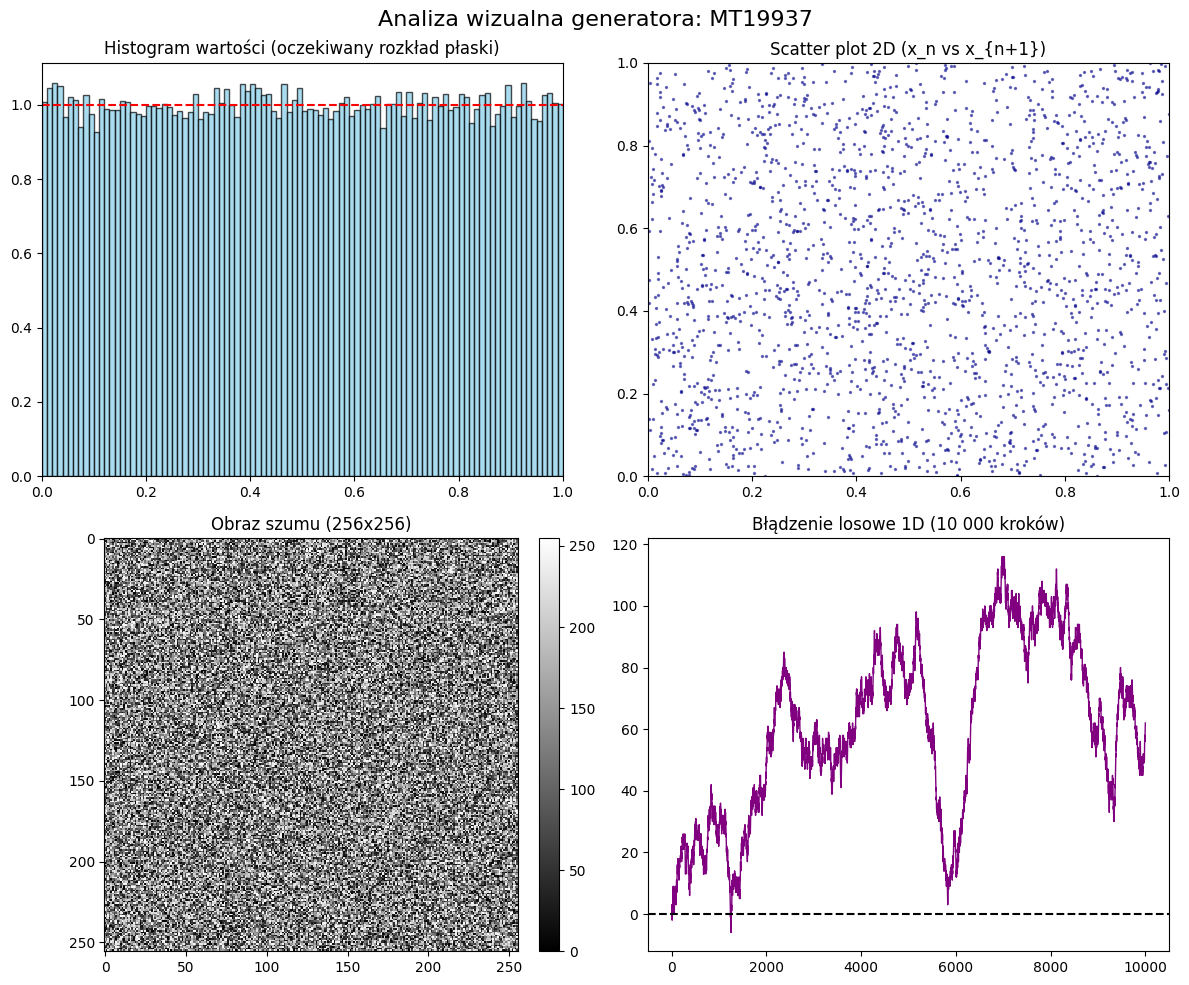

In [10]:
generator = MT19937Generator(seed=12345)
results = validate_generator(generator, cfg)
print(json.dumps(results, indent=2))
run_visual_tests(generator)

## Permuted Congruential Generator (PCG64)

Implementacja: `numpy.random.PCG64`.

Charakterystyka: Nowoczesny generator PRNG, który rozwiązuje problemy LCG. Wykorzystuje liniowy silnik do aktualizacji stanu, ale stosuje permutacje wyjścia (XSH-RR: fixed bit rotation), co poprawia właściwości statystyczne przy zachowaniu wysokiej wydajności.

{
  "generator": "PCG64",
  "summary_numbers": {
    "count": 5000.0,
    "mean": 9.151741213837307e+18,
    "variance": 2.781678232701151e+37,
    "std": 5.274161765343524e+18,
    "min": 2717393736811790.0,
    "max": 1.8441741728854139e+19
  },
  "summary_floats": {
    "count": 5000.0,
    "mean": 0.49577337676197003,
    "variance": 0.08225425520684297,
    "std": 0.28680002651123127,
    "min": 4.022119237012678e-05,
    "max": 0.9996428034687773
  },
  "bit_balance": {
    "count": 10000,
    "zeros": 4976,
    "ones": 5024,
    "p_zero": 0.4976,
    "p_one": 0.5024
  },
  "serial_pairs": {
    "00": 2477,
    "01": 2499,
    "10": 2499,
    "11": 2524
  },
  "tests": {
    "monobit": {
      "statistic": 0.48,
      "p_value": 0.6312273930324452,
      "pass": true
    },
    "runs": {
      "statistic": 4999.0,
      "p_value": 0.9858810464201462,
      "pass": true
    },
    "chi_square_uint64_mod_256": {
      "statistic": 272.2688,
      "p_value": 0.21845309067808807,
   

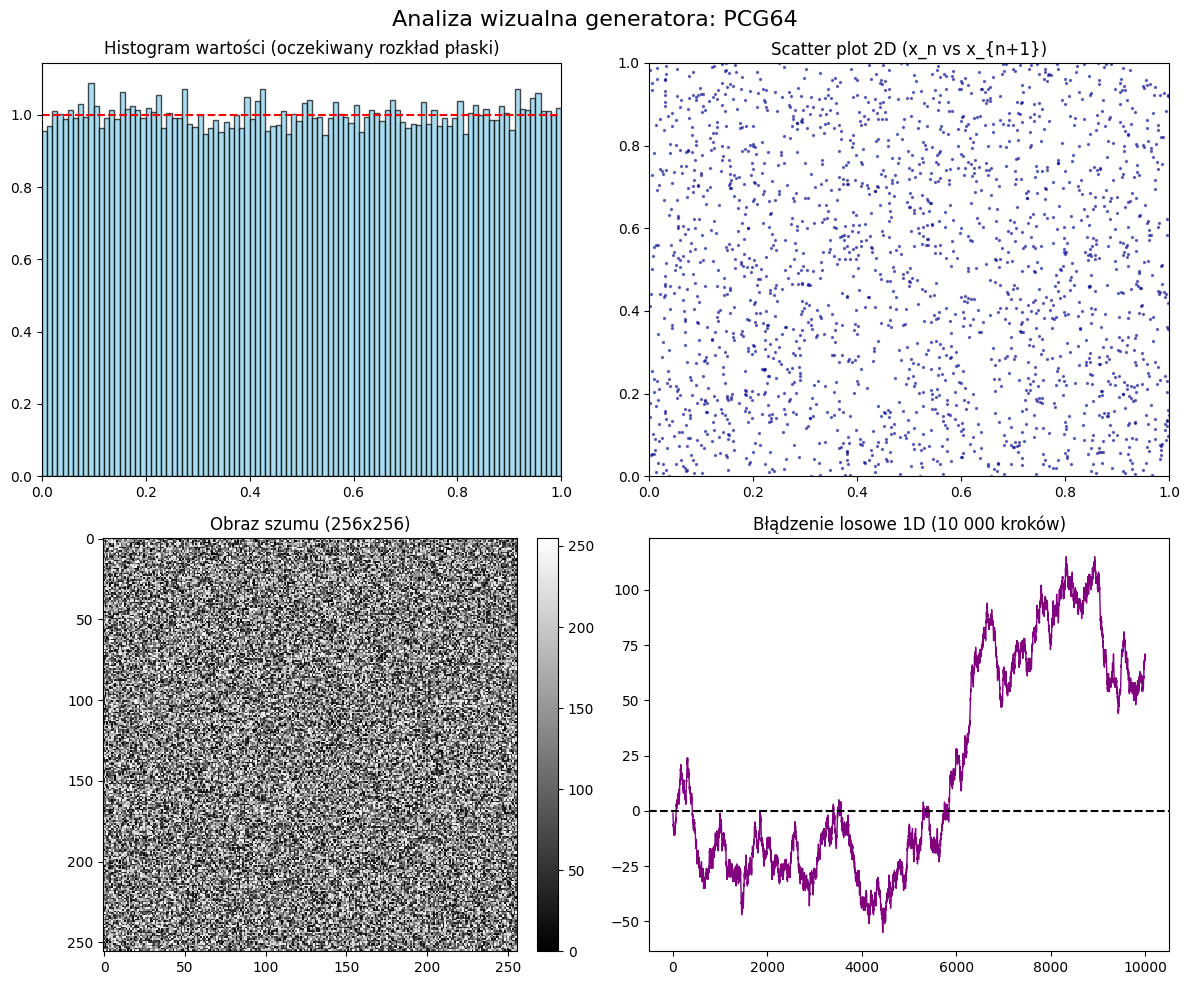

In [11]:
generator = PCG64Generator(seed=12345)
results = validate_generator(generator, cfg)
print(json.dumps(results, indent=2))
run_visual_tests(generator)

## System CSPRNG (os.urandom)

Mechanizm: Interfejs do systemowego źródła entropii (np. `/dev/urandom` w Linux lub `BCryptGenRandom` w Windows).

Charakterystyka: Generator nieprzewidywalny (CSPRNG). Pobiera entropię z niedeterministycznych zdarzeń systemowych (przerwania sprzętowe, czasy dostępu do dysku).

{
  "generator": "SystemCSPRNG",
  "summary_numbers": {
    "count": 5000.0,
    "mean": 9.172266634041217e+18,
    "variance": 2.8365067497992474e+37,
    "std": 5.325886545730436e+18,
    "min": 2105211998851919.0,
    "max": 1.8435141772434596e+19
  },
  "summary_floats": {
    "count": 5000.0,
    "mean": 0.5079958220333363,
    "variance": 0.08403095498128546,
    "std": 0.28988093242102947,
    "min": 0.00040391887795624434,
    "max": 0.9996241337084849
  },
  "bit_balance": {
    "count": 10000,
    "zeros": 5126,
    "ones": 4874,
    "p_zero": 0.5126,
    "p_one": 0.4874
  },
  "serial_pairs": {
    "00": 2633,
    "01": 2493,
    "10": 2493,
    "11": 2380
  },
  "tests": {
    "monobit": {
      "statistic": 2.52,
      "p_value": 0.011735483430665133,
      "pass": true
    },
    "runs": {
      "statistic": 4987.0,
      "p_value": 0.8441242436867812,
      "pass": true
    },
    "chi_square_uint64_mod_256": {
      "statistic": 266.1248,
      "p_value": 0.303259768599

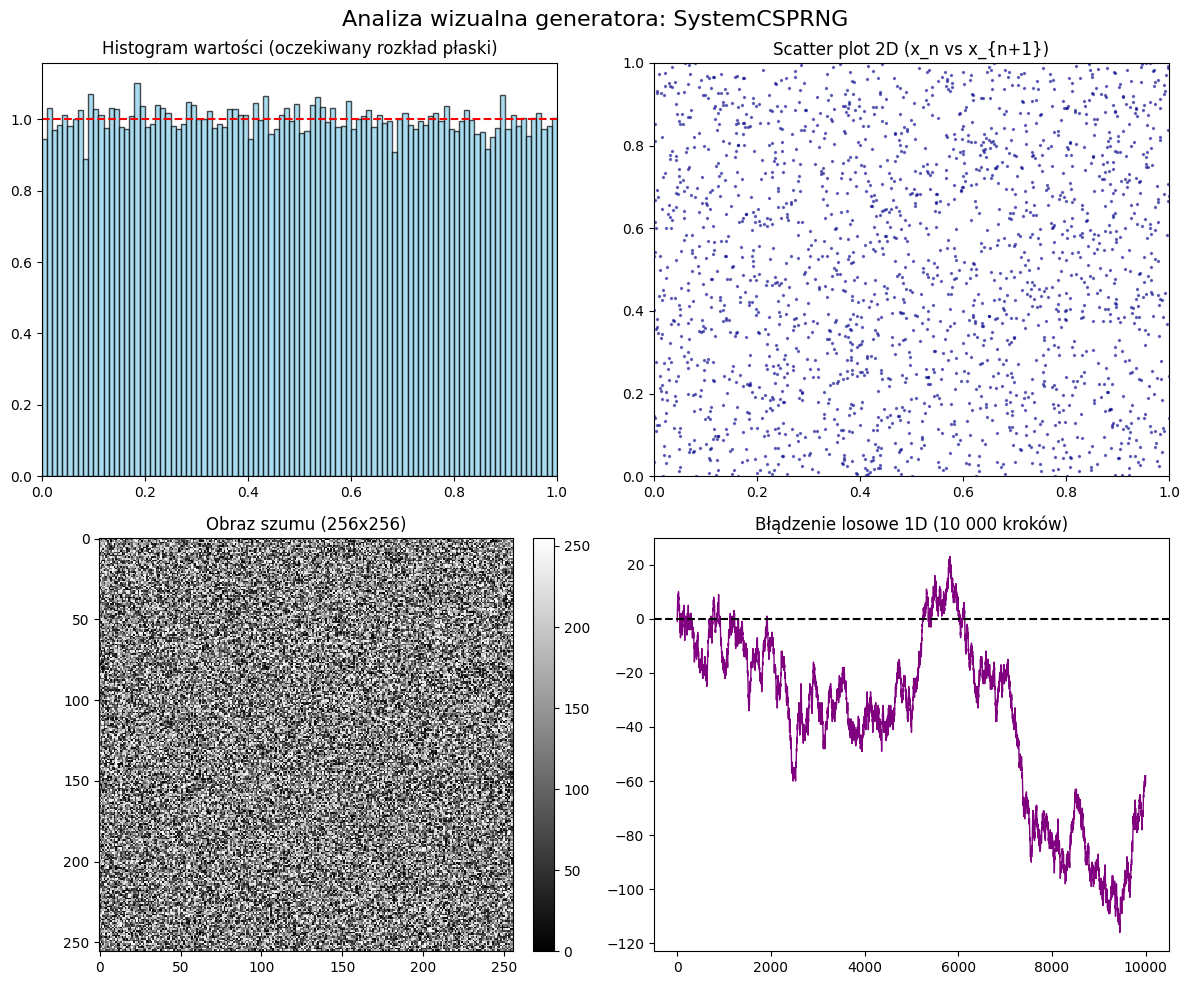

In [12]:
generator = SystemCSPRNG()
results = validate_generator(generator, cfg)
print(json.dumps(results, indent=2))
run_visual_tests(generator)

## HMAC_DRBG (Deterministic Random Bit Generator)

Zgodność: Inspirowany standardem NIST SP 800-90A.

Mechanizm: Wykorzystuje funkcję skrótu SHA-256 oraz mechanizm HMAC do aktualizacji wewnętrznego stanu.

Charakterystyka: Jest to deterministyczny generator kryptograficzny. Gwarantuje, że przy znajomości wyjścia, odtworzenie ziarna (seed) lub przewidzenie następnych bitów jest obliczeniowo niewykonalne (bezpieczeństwo oparte na trudności odwrócenia funkcji SHA-256).

{
  "generator": "HMAC_DRBG_SHA256",
  "summary_numbers": {
    "count": 5000.0,
    "mean": 9.271077448277029e+18,
    "variance": 2.834316872783472e+37,
    "std": 5.323830268503563e+18,
    "min": 3577667591172631.0,
    "max": 1.8446255969852869e+19
  },
  "summary_floats": {
    "count": 5000.0,
    "mean": 0.5016975008014241,
    "variance": 0.08308713019860671,
    "std": 0.2882483828204535,
    "min": 9.440401233452362e-05,
    "max": 0.9998527670017062
  },
  "bit_balance": {
    "count": 10000,
    "zeros": 4928,
    "ones": 5072,
    "p_zero": 0.4928,
    "p_one": 0.5072
  },
  "serial_pairs": {
    "00": 2436,
    "01": 2491,
    "10": 2491,
    "11": 2581
  },
  "tests": {
    "monobit": {
      "statistic": 1.44,
      "p_value": 0.14986739906865412,
      "pass": true
    },
    "runs": {
      "statistic": 4983.0,
      "p_value": 0.7494761218571901,
      "pass": true
    },
    "chi_square_uint64_mod_256": {
      "statistic": 234.0736,
      "p_value": 0.822136723529

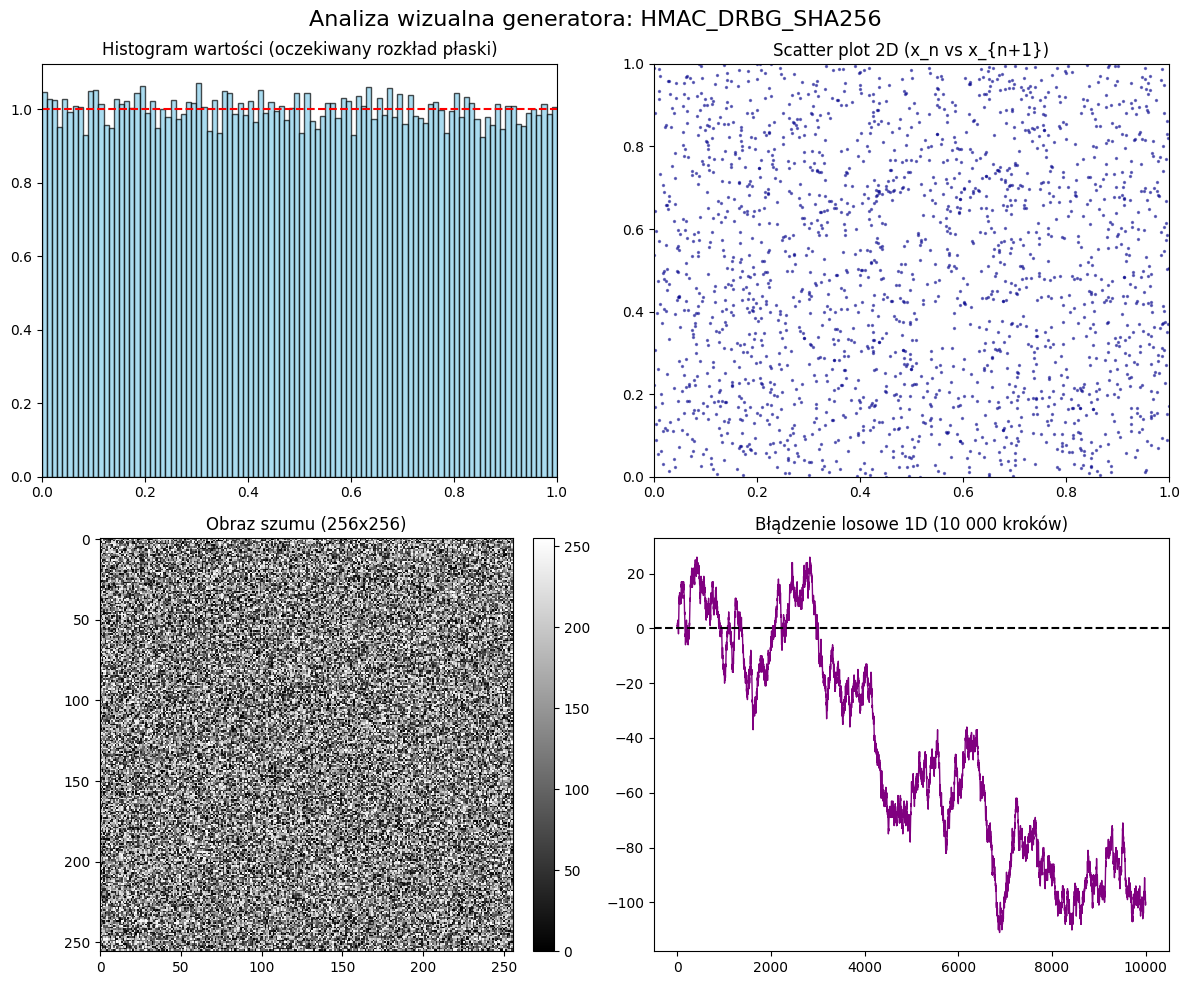

In [13]:
generator = HMACDRBG(entropy=b"example-entropy-seed-32-bytes!!!!", nonce=b"demo")
results = validate_generator(generator, cfg)
print(json.dumps(results, indent=2))
run_visual_tests(generator)

## MockTRNG (Symulowany TRNG)

Model: Symulacja fizycznego źródła entropii obarczonego błędami.

Mechanizm:
1. Generowanie "brudnych" bitów z zadanym obciążeniem (bias = 0.52) i korelacją.
2. Conditioning: Przepuszczenie surowych danych przez funkcję SHA-256 w celu "wybielenia" (whitening) statystyk.

Cel: Pokazanie, jak w rzeczywistych systemach surowa, niedoskonała entropia fizyczna jest przetwarzana na "idealny" rozkład.

{
  "generator": "MockTRNG",
  "summary_numbers": {
    "count": 5000.0,
    "mean": 9.207176373834114e+18,
    "variance": 2.824782993527551e+37,
    "std": 5.314868759929591e+18,
    "min": 7736484280057782.0,
    "max": 1.8446476802435645e+19
  },
  "summary_floats": {
    "count": 5000.0,
    "mean": 0.5000908933902921,
    "variance": 0.0845813052604615,
    "std": 0.29082865275013997,
    "min": 0.00032962067212963605,
    "max": 0.9997878331474283
  },
  "bit_balance": {
    "count": 10000,
    "zeros": 5005,
    "ones": 4995,
    "p_zero": 0.5005,
    "p_one": 0.4995
  },
  "serial_pairs": {
    "00": 2542,
    "01": 2462,
    "10": 2462,
    "11": 2533
  },
  "tests": {
    "monobit": {
      "statistic": 0.1,
      "p_value": 0.920344325445942,
      "pass": true
    },
    "runs": {
      "statistic": 4925.0,
      "p_value": 0.1336399194145513,
      "pass": true
    },
    "chi_square_uint64_mod_256": {
      "statistic": 254.144,
      "p_value": 0.5033560641926765,
     

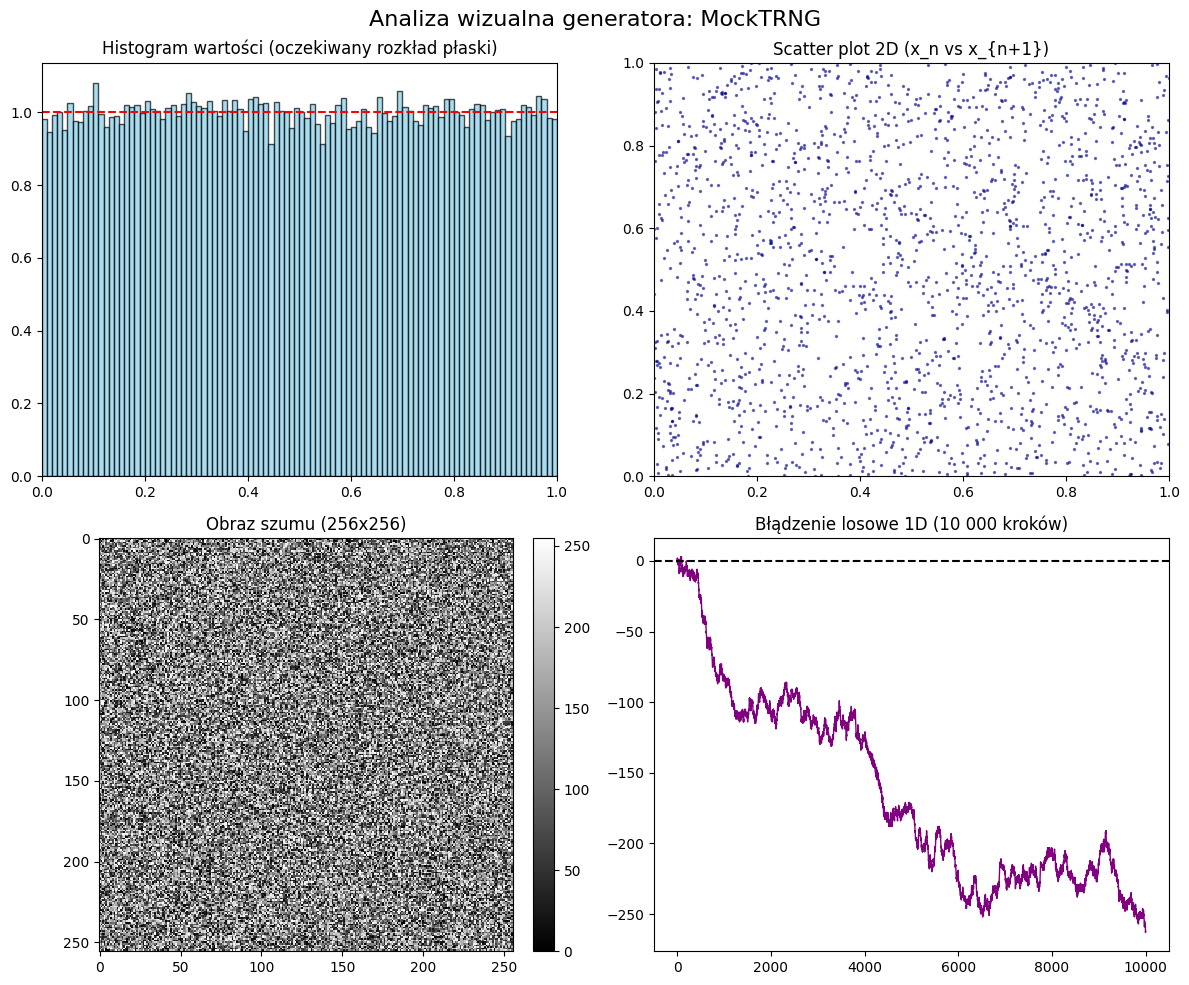

In [14]:
generator = MockTRNG(seed=12345)
results = validate_generator(generator, cfg)
print(json.dumps(results, indent=2))
run_visual_tests(generator)

## Mapa Logistyczna (Logistic Map)

Charakterystyka: Generator oparty na dynamice układów nieliniowych. Choć deterministyczny, wykazuje ogromną wrażliwość na warunki początkowe. W analizie służy jako przykład generatora, który "wygląda" na losowy, ale posiada niefizyczny, niejednorodny rozkład prawdopodobieństwa (mapa logistyczna).

{
  "generator": "LogisticMap",
  "summary_numbers": {
    "count": 5000.0,
    "mean": 9.942091642651548e+18,
    "variance": 2.399978156439111e+37,
    "std": 4.898957191524652e+18,
    "min": 1.2301375136985987e+18,
    "max": 1.8444745053416518e+19
  },
  "summary_floats": {
    "count": 5000.0,
    "mean": 0.5321724569568842,
    "variance": 0.11562472062031022,
    "std": 0.34003635191007187,
    "min": 0.009961825838661847,
    "max": 0.9974970369708965
  },
  "bit_balance": {
    "count": 10000,
    "zeros": 4593,
    "ones": 5407,
    "p_zero": 0.4593,
    "p_one": 0.5407
  },
  "serial_pairs": {
    "00": 1931,
    "01": 2661,
    "10": 2661,
    "11": 2746
  },
  "tests": {
    "monobit": {
      "statistic": 8.14,
      "p_value": 3.95277897170999e-16,
      "pass": false
    },
    "runs": {
      "statistic": NaN,
      "p_value": 0.0,
      "pass": false
    },
    "chi_square_uint64_mod_256": {
      "statistic": 2151.3088,
      "p_value": 9.626929470278214e-297,
     

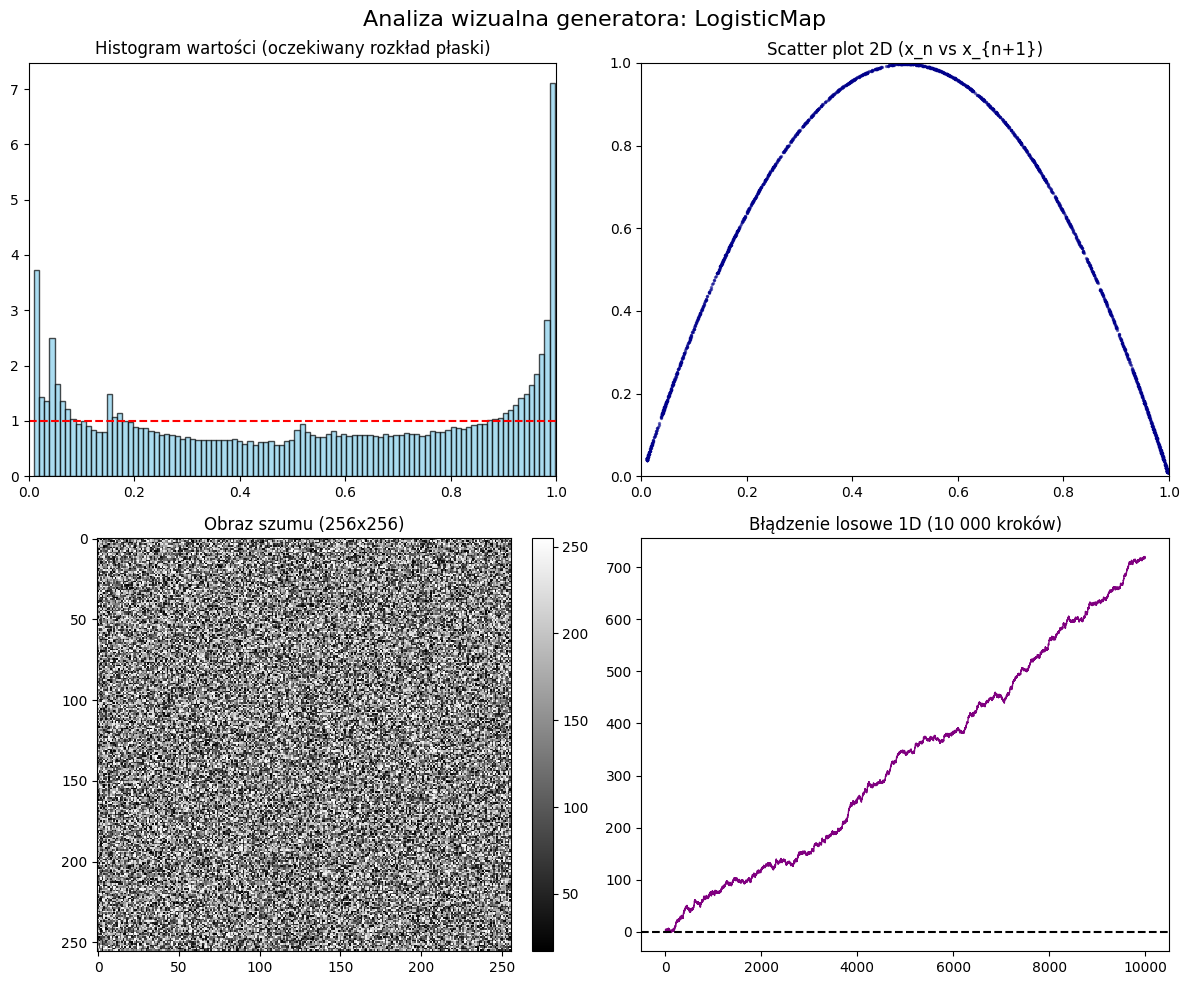

In [15]:
generator = LogisticMapGenerator(x0=0.314159265, r=3.99)
results = validate_generator(generator, cfg)
print(json.dumps(results, indent=2))
run_visual_tests(generator)